In [176]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,roc_curve,precision_recall_curve, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
columns = [
'duration',
'protocol_type',
'service',
'flag',
'src_bytes',
'dst_bytes',
'land',
'wrong_fragment',
'urgent',
'hot',
'num_failed_logins',
'logged_in',
'num_compromised',
'root_shell',
'su_attempted',
'num_root',
'num_file_creations',
'num_shells',
'num_access_files',
'num_outbound_cmds',
'is_host_login',
'is_guest_login',
'count',
'srv_count',
'serror_rate',
'srv_serror_rate',
'rerror_rate',
'srv_rerror_rate',
'same_srv_rate',
'diff_srv_rate',
'srv_diff_host_rate',
'dst_host_count',
'dst_host_srv_count',
'dst_host_same_srv_rate',
'dst_host_diff_srv_rate',
'dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate',
'dst_host_serror_rate',
'dst_host_srv_serror_rate',
'dst_host_rerror_rate',
'dst_host_srv_rerror_rate',
'attack',
'difficulty'
]

In [3]:
df1 = pd.read_csv("Data/train.txt",names=columns)
df2 = pd.read_csv("Data/test.txt",names=columns)

In [4]:
df1.head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
5,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21
6,0,tcp,private,S0,0,0,0,0,0,0,...,0.04,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
7,0,tcp,private,S0,0,0,0,0,0,0,...,0.06,0.07,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
8,0,tcp,remote_job,S0,0,0,0,0,0,0,...,0.09,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
9,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21


In [5]:
df1["attack"] = df1["attack"].apply(lambda x:0 if x=="normal" else 1)
df2["attack"] = df2["attack"].apply(lambda x:0 if x=="normal" else 1)

In [6]:
df1["wrong_fragment"].unique()

array([0, 3, 1])

In [7]:
df1["dst_host_srv_rerror_rate"].value_counts()

dst_host_srv_rerror_rate
0.00    106616
1.00     13231
0.01      1390
0.02       580
0.03       352
         ...  
0.30         6
0.28         5
0.21         5
0.26         3
0.43         3
Name: count, Length: 101, dtype: int64

In [8]:
pd.crosstab(df1["num_access_files"], df1["attack"])

attack,0,1
num_access_files,,
0,66982,58620
1,304,9
2,28,1
3,8,0
4,5,0
5,6,0
6,4,0
7,2,0
8,3,0


In [9]:
df1["attack"].unique()

array([0, 1])

In [10]:
df1.drop("difficulty",axis=1,inplace=True)
df2.drop("difficulty",axis=1,inplace=True)

In [11]:
df1["attack"].value_counts()

attack
0    67343
1    58630
Name: count, dtype: int64

In [180]:
corr = df1.corr(numeric_only = True)

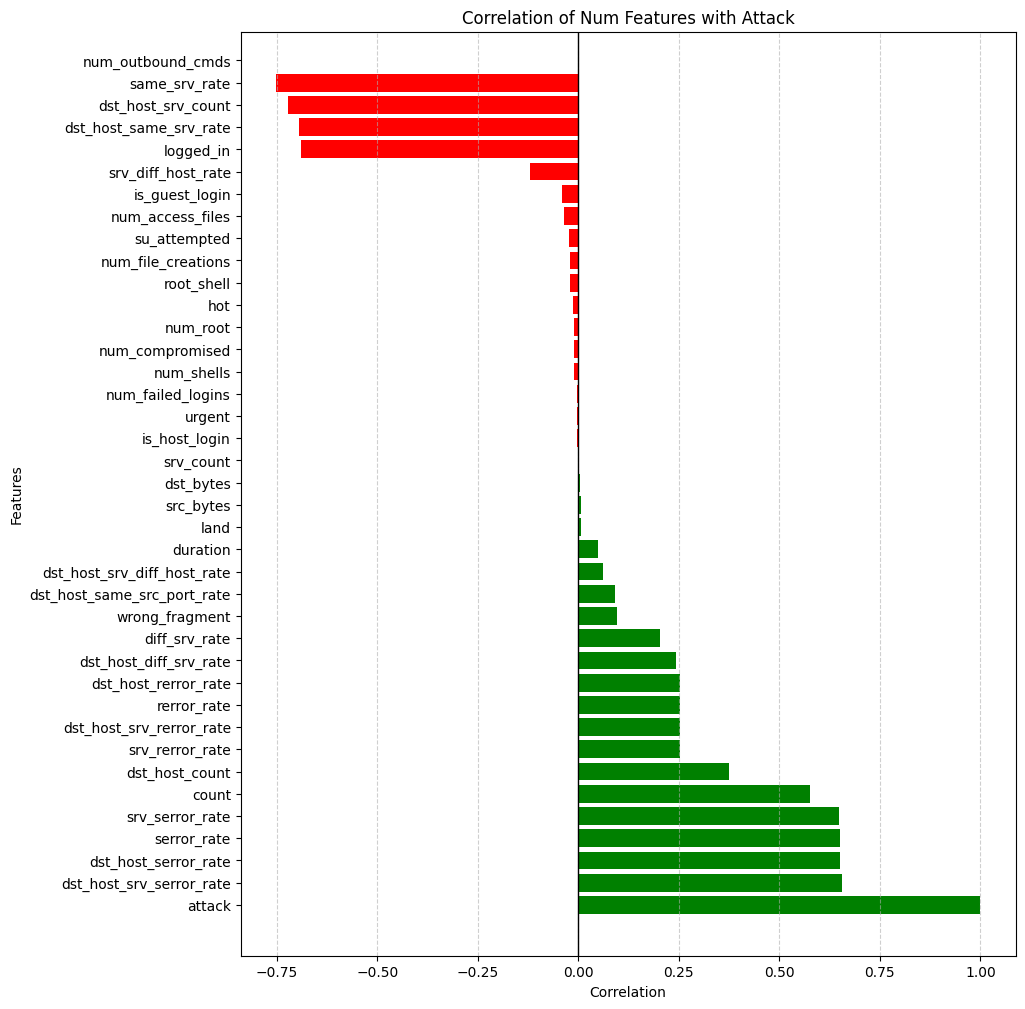

In [188]:
corr_attack = corr["attack"].sort_values(ascending=False)
plt.figure(figsize=(10, 12))
colors = ["red" if x < 0 else "green" for x in corr_attack]
plt.axvline(0, color="black", linewidth=1)
plt.barh(corr_attack.index, corr_attack.values,color=colors)
plt.title("Correlation of Num Features with Attack")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.6)

In [14]:
x_train = df1.drop("attack",axis=1)
y_train = df1["attack"]

In [15]:
x_test = df2.drop("attack",axis=1)
y_test = df2["attack"]

In [16]:
(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

((125973, 41), (125973,), (22544, 41), (22544,))

In [17]:
num_attribute = []
cat_attribute = []
for col in x_train.columns :
    if df1[col].dtype == "object":
        cat_attribute.append(col)
    else:
        num_attribute.append(col)
num_pipeline = Pipeline([
    ('Scaler',StandardScaler())
])
cat_pipeline = Pipeline([
    ('Onehot',OneHotEncoder(handle_unknown='ignore'))
])
full_pipeline = ColumnTransformer([
    ("num",num_pipeline,num_attribute),
    ("cat",cat_pipeline,cat_attribute)
])

In [18]:
lr = make_pipeline(full_pipeline,LogisticRegression(n_jobs=-1))
lr.fit(x_train,y_train)

C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differe

In [19]:
pred = lr.predict(x_test)

In [20]:
lr.score(x_test,y_test)

0.7532381121362669

In [21]:
confusion_matrix(y_test,pred)

array([[8991,  720],
       [4843, 7990]])

In [22]:
dt = make_pipeline(full_pipeline,DecisionTreeClassifier(random_state=42))
dt.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

In [23]:
pred = dt.predict(x_test)

In [24]:
dt.score(x_test,y_test)

0.7854418026969482

In [25]:
confusion_matrix(y_test,pred)

array([[9408,  303],
       [4534, 8299]])

In [26]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.67      0.97      0.80      9711
           1       0.96      0.65      0.77     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.78     22544
weighted avg       0.84      0.79      0.78     22544



In [27]:
rc = make_pipeline(full_pipeline,RandomForestClassifier(random_state=42,n_jobs=-1))
rc.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('randomforestclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

In [28]:
pred = rc.predict(x_test)

In [29]:
rc.score(x_test,y_test)

0.7647711142654364

In [30]:
confusion_matrix(y_test,pred)

array([[9445,  266],
       [5037, 7796]])

In [31]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.65      0.97      0.78      9711
           1       0.97      0.61      0.75     12833

    accuracy                           0.76     22544
   macro avg       0.81      0.79      0.76     22544
weighted avg       0.83      0.76      0.76     22544



In [32]:
rc = make_pipeline(full_pipeline,RandomForestClassifier(random_state=42,n_jobs=-1))
param_grid = {
    "randomforestclassifier__n_estimators":[100,200],
    "randomforestclassifier__max_depth":[10,20,None],
    "randomforestclassifier__min_samples_split":[2,5],
    "randomforestclassifier__min_samples_leaf":[1,2],
    "randomforestclassifier__max_features": ["sqrt", "log2"]
}
grid_search = GridSearchCV(
    rc,
    param_grid,
    cv=5,
    scoring="recall",
    error_score="raise"
)
grid_search.fit(x_train,y_train)
model = grid_search.best_estimator_
model.score(x_test,y_test)

0.7676543647977289

In [33]:
grid_search.best_params_

{'randomforestclassifier__max_depth': None,
 'randomforestclassifier__max_features': 'sqrt',
 'randomforestclassifier__min_samples_leaf': 1,
 'randomforestclassifier__min_samples_split': 2,
 'randomforestclassifier__n_estimators': 200}

In [34]:
dt = make_pipeline(full_pipeline,DecisionTreeClassifier(random_state=42))
param_grid = {
    "decisiontreeclassifier__max_depth":[10,20,None],
    "decisiontreeclassifier__min_samples_split":[2,5],
    "decisiontreeclassifier__min_samples_leaf":[1,2],
    "decisiontreeclassifier__criterion":["gini","entropy"]
}
grid_search = GridSearchCV(
    dt,
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring="recall",
    error_score="raise"
)
grid_search.fit(x_train,y_train)
model = grid_search.best_estimator_
model.score(x_test,y_test)

0.7772799858055358

In [35]:
grid_search.best_params_

{'decisiontreeclassifier__criterion': 'entropy',
 'decisiontreeclassifier__max_depth': 20,
 'decisiontreeclassifier__min_samples_leaf': 1,
 'decisiontreeclassifier__min_samples_split': 2}

In [36]:
rf = model.named_steps["decisiontreeclassifier"]
importance = rf.feature_importances_
feature_names = model.named_steps["columntransformer"].get_feature_names_out()
feature_importance = pd.DataFrame({
    "Feature":feature_names,
    "importance":importance
}).sort_values("importance",ascending=False)

In [37]:
feature_importance.head(20)

,Feature,importance
1,num__src_bytes,0.639525
56,cat__service_ecr_i,0.087455
26,num__diff_srv_rate,0.079495
65,cat__service_http,0.042168
6,num__hot,0.040436
2,num__dst_bytes,0.029947
32,num__dst_host_same_src_port_rate,0.023876
61,cat__service_ftp_data,0.012872
29,num__dst_host_srv_count,0.007125
0,num__duration,0.006162


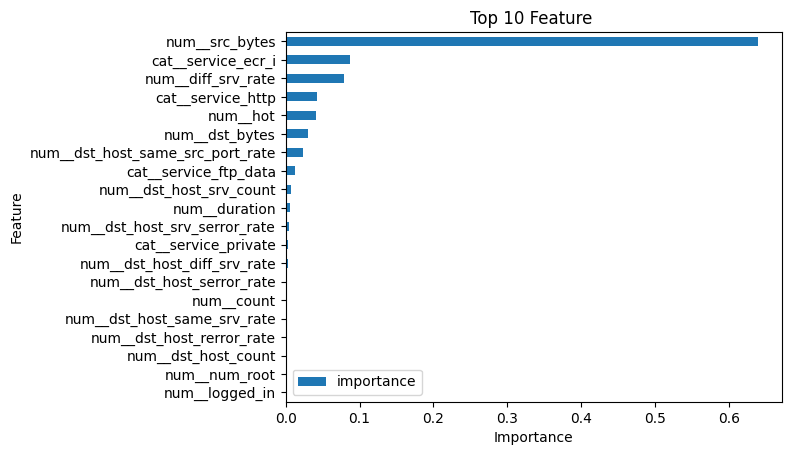

In [136]:
imp = []
for i in range(0,30):
    imp.append(feature_importance["Feature"][i])
feature_importance.head(20).plot(kind="barh",x="Feature",y="importance")
plt.ylabel("Feature")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.title("Top 10 Feature ")
plt.show()

In [137]:
feature_names
top_num_attribute = []
top_cat_attribute = []
names =[]
for i in imp:
    ch = i.split("__")[1]
    if i.startswith("num__"):
        top_num_attribute.append(ch)
        names.append(ch)
    else:
        if ch[0]=='p' and "protocol_type" not in names:
            top_cat_attribute.append("protocol_type")
            names.append("protocol_type")
        elif ch[0]=='s' and "service" not in names:
            names.append("service")
            top_cat_attribute.append("service")
        elif ch[0]=='f' and "flag" not in names:
            top_cat_attribute.append("flag")
            names.append("flag")

In [138]:
x_top_train = x_train[names]
y_top_train = y_train
x_top_test = x_test[names]
y_top_test = y_test

In [139]:
num_pipeline = Pipeline([
    ('Scaler',StandardScaler())
])
cat_pipeline = Pipeline([
    ('Onehot',OneHotEncoder(handle_unknown='ignore'))
])
full_pipeline = ColumnTransformer([
    ("num",num_pipeline,top_num_attribute),
    ("cat",cat_pipeline,top_cat_attribute)
])

In [140]:
rc = make_pipeline(full_pipeline,RandomForestClassifier(random_state=42,n_jobs=-1))
rc.fit(x_top_train,y_top_train)
pred = rc.predict(x_top_test)
print(rc.score(x_top_test,y_top_test))
print(confusion_matrix(y_top_test,pred))
print(classification_report(y_top_test,pred))

0.7597586941092974
[[9437  274]
 [5142 7691]]
              precision    recall  f1-score   support

           0       0.65      0.97      0.78      9711
           1       0.97      0.60      0.74     12833

    accuracy                           0.76     22544
   macro avg       0.81      0.79      0.76     22544
weighted avg       0.83      0.76      0.76     22544



In [49]:
rc = make_pipeline(full_pipeline,RandomForestClassifier(random_state=42,n_jobs=-1))
param_grid = {
    "randomforestclassifier__n_estimators":[100,200],
    "randomforestclassifier__max_depth":[10,20,None],
    "randomforestclassifier__min_samples_split":[2,5],
    "randomforestclassifier__min_samples_leaf":[1,2],
    "randomforestclassifier__max_features": ["sqrt", "log2"]
}
grid_search = GridSearchCV(
    rc,
    param_grid,
    cv=5,
    scoring="recall",
    error_score="raise"
)
grid_search.fit(x_top_train,y_top_train)
model = grid_search.best_estimator_
model.score(x_top_test,y_top_test)

0.7700053229240597

In [141]:
dt = make_pipeline(full_pipeline,DecisionTreeClassifier(random_state=42))
param_grid = {
    "decisiontreeclassifier__max_depth":[10,20,None],
    "decisiontreeclassifier__min_samples_split":[2,5],
    "decisiontreeclassifier__min_samples_leaf":[1,2],
    "decisiontreeclassifier__criterion":["gini","entropy"]
}
grid_search = GridSearchCV(
    dt,
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring="recall",
    error_score="raise"
)
grid_search.fit(x_top_train,y_top_train)
model = grid_search.best_estimator_
model.score(x_top_test,y_top_test)

0.810681334279631

In [161]:
pred = model.predict(x_top_test)
print(confusion_matrix(y_top_test,pred))

[[9421  290]
 [3978 8855]]


In [162]:
print(classification_report(y_top_test,pred))

              precision    recall  f1-score   support

           0       0.70      0.97      0.82      9711
           1       0.97      0.69      0.81     12833

    accuracy                           0.81     22544
   macro avg       0.84      0.83      0.81     22544
weighted avg       0.85      0.81      0.81     22544



ROC-AUC Score: 0.8338693092847246


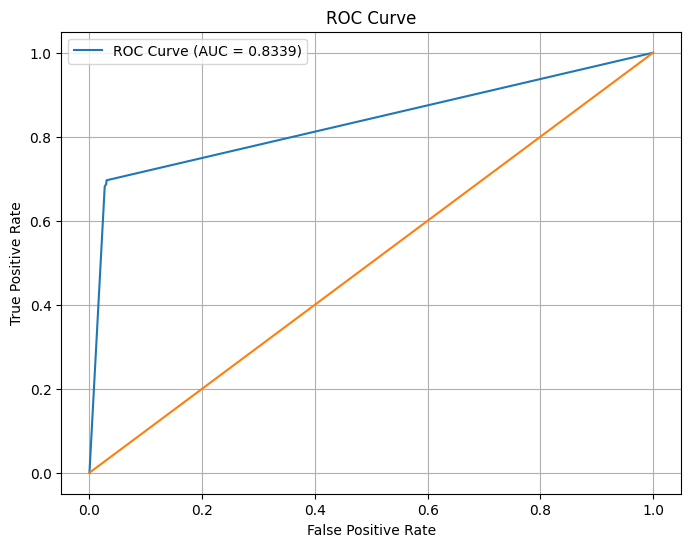

In [174]:
fpr, tpr, threshold = roc_curve(y_top_test, y_prob)
roc_auc = roc_auc_score(y_top_test, y_prob)

print("ROC-AUC Score:", roc_auc)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [172]:
y_prob = model.predict_proba(x_top_test)[:,1]

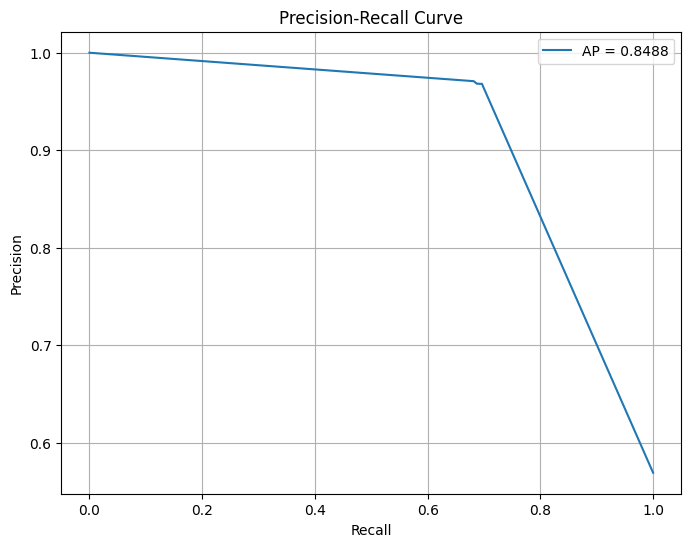

In [175]:
precision, recall, _ = precision_recall_curve(y_top_test, y_prob)
ap = average_precision_score(y_top_test, y_prob)
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.legend()
plt.show()